# Employee Analytics using ML 
## Salary and Promotion Prediction 

### Importing Libraries

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

### Loading The Dataset

In [8]:
df= pd.read_csv(r"D:\DATA_SCIENCE\employee_promotion_prediction.csv")
df

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,58,Male,Bachelor,Married,Tier1,HR,Full-time,7,7,...,66709.407346,8.631959,8702.015281,5974.691684,0.869204,0,50.969019,40.829720,70.007765,0
99996,99997,48,Female,PhD,Married,Tier1,Sales,Full-time,1,1,...,126692.866136,8.298289,11794.937090,4772.987201,0.881698,2,66.858201,73.062241,52.235678,0
99997,99998,44,Male,Master,Single,Tier1,Marketing,Full-time,6,5,...,97701.247923,3.808966,12290.380251,4933.996464,0.880806,2,77.376189,33.173988,80.104191,0
99998,99999,47,Female,Master,Single,Tier2,Operations,Full-time,10,0,...,92976.123220,7.207749,6013.059244,5050.752021,0.943993,1,84.417142,55.164958,27.788739,0


In [9]:
print(df.columns)

Index(['employee_id', 'age', 'gender', 'education_level', 'marital_status',
       'city_tier', 'department', 'employment_type', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion', 'team_size',
       'performance_score', 'performance_last_year',
       'performance_two_years_ago', 'manager_rating', 'peer_feedback_score',
       'projects_completed', 'kpi_achievement_percent', 'innovation_score',
       'leadership_score', 'problem_solving_score', 'avg_monthly_hours',
       'overtime_hours', 'tasks_completed', 'deadline_adherence_rate',
       'meeting_hours_per_month', 'remote_work_ratio',
       'training_hours_last_year', 'certifications_count',
       'skill_assessment_score', 'cross_department_projects',
       'mentoring_sessions', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate', 'late_days',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'promoted'],


In [10]:
data = df [['age','years_at_company','performance_score','training_hours_last_year','projects_completed','salary','promoted']]
data

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary,promoted
0,50,10,100.000000,25.361303,4,137633.720337,0
1,36,9,72.008233,43.760654,9,114499.406460,0
2,29,7,77.244045,25.275693,7,124233.224752,0
3,42,4,49.061426,33.507680,4,100896.326509,0
4,40,2,89.021698,44.730269,6,93054.051809,0
...,...,...,...,...,...,...,...
99995,58,7,65.667405,44.196447,2,66709.407346,0
99996,48,1,65.879533,28.214698,4,126692.866136,0
99997,44,6,74.019251,47.025932,4,97701.247923,0
99998,47,10,42.735590,53.422399,9,92976.123220,0


### Data Information Gathering

In [11]:
data.tail(20)

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary,promoted
99980,55,8,66.538667,38.999212,5,87865.242698,0
99981,47,1,65.938826,55.357791,3,71836.048263,0
99982,26,1,95.158363,34.929375,5,105651.695571,0
99983,27,8,73.893869,28.504333,6,111631.816850,0
99984,53,10,69.451201,45.328043,3,114489.659608,0
99985,53,6,81.636422,59.687661,0,91808.768059,0
99986,29,3,65.108404,33.974458,1,83177.429051,0
99987,39,2,47.382657,50.867111,1,136748.177842,0
99988,22,5,58.632218,43.419707,6,93763.695938,0
99989,45,3,79.729359,22.752892,11,102438.211771,0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       100000 non-null  int64  
 1   years_at_company          100000 non-null  int64  
 2   performance_score         100000 non-null  float64
 3   training_hours_last_year  100000 non-null  float64
 4   projects_completed        100000 non-null  int64  
 5   salary                    100000 non-null  float64
 6   promoted                  100000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 5.3 MB


In [13]:
data.describe()

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary,promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,40.558140,5.489030,70.097429,43.351966,5.444740,101729.791058,0.100000
std,10.951788,3.481758,14.717013,17.800025,3.865177,36260.885391,0.300002
min,22.000000,0.000000,40.000000,0.000000,0.000000,27616.720722,0.000000
25%,31.000000,3.000000,59.499890,33.765025,3.000000,83242.514699,0.000000
50%,41.000000,5.000000,69.980013,42.038934,5.000000,96923.478362,0.000000
75%,50.000000,7.000000,80.596442,50.411928,7.000000,112448.432831,0.000000
max,59.000000,30.000000,100.000000,322.950883,80.000000,663817.278916,1.000000


In [14]:
data.shape

(100000, 7)

### Data Cleaning

In [15]:
data.isnull().sum()

age                         0
years_at_company            0
performance_score           0
training_hours_last_year    0
projects_completed          0
salary                      0
promoted                    0
dtype: int64

In [16]:
data.duplicated().sum()

np.int64(0)

### Data Visualization

<Axes: >

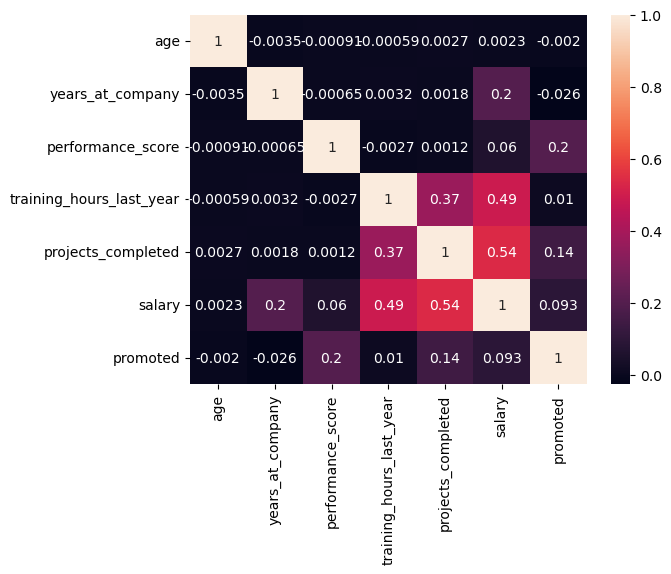

In [17]:
sns.heatmap(data.corr(),annot=True)

# A. Multiple Linear Regression
## Predict Employee Salary Based On Performance and Experience

### Divide X and Y

In [18]:
X = data[['age','years_at_company','performance_score','training_hours_last_year','projects_completed']]
Y = data['salary']
X

,age,years_at_company,performance_score,training_hours_last_year,projects_completed
0,50,10,100.000000,25.361303,4
1,36,9,72.008233,43.760654,9
2,29,7,77.244045,25.275693,7
3,42,4,49.061426,33.507680,4
4,40,2,89.021698,44.730269,6
...,...,...,...,...,...
99995,58,7,65.667405,44.196447,2
99996,48,1,65.879533,28.214698,4
99997,44,6,74.019251,47.025932,4
99998,47,10,42.735590,53.422399,9


In [19]:
Y

0        137633.720337
1        114499.406460
2        124233.224752
3        100896.326509
4         93054.051809
             ...      
99995     66709.407346
99996    126692.866136
99997     97701.247923
99998     92976.123220
99999     60513.833314
Name: salary, Length: 100000, dtype: float64

### Train-Test Split

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2 , random_state = 42)
X_train

,age,years_at_company,performance_score,training_hours_last_year,projects_completed
75220,23,5,47.824264,20.754975,9
48955,23,7,64.516715,15.313036,6
44966,52,3,63.665210,48.493965,5
13568,42,11,96.233573,33.491824,7
92727,28,3,86.196355,54.513109,8
...,...,...,...,...,...
6265,59,5,63.327825,41.129169,3
54886,33,6,96.846375,44.624456,10
76820,22,9,51.347495,40.713442,4
860,47,6,73.290585,32.195541,4


In [21]:
Y_train

75220    102103.342993
48955     82977.988533
44966     83469.439859
13568     99228.546461
92727    114434.758009
             ...      
6265      75973.556626
54886    151220.897952
76820    107776.236142
860       80798.729980
15795    322471.986631
Name: salary, Length: 80000, dtype: float64

In [22]:
X_test

,age,years_at_company,performance_score,training_hours_last_year,projects_completed
75721,48,11,61.569049,46.592282,5
80184,54,6,44.909208,34.671245,8
19864,40,1,84.727623,54.084261,2
76699,37,4,40.000000,24.813713,2
92991,59,3,56.061030,30.549544,1
...,...,...,...,...,...
32595,36,5,75.844916,23.309500,2
29313,38,2,63.002196,38.890553,5
37862,38,7,57.035322,52.725140,1
53421,22,4,47.058619,36.250124,5


In [23]:
Y_test

75721    127269.603922
80184    104196.216921
19864     75473.743918
76699    110146.167810
92991     70457.941373
             ...      
32595     91193.256924
29313    106675.027402
37862     95890.907997
53421     65646.026553
42410     91763.726878
Name: salary, Length: 20000, dtype: float64

### Feature Scaling

In [24]:
X.columns

Index(['age', 'years_at_company', 'performance_score',
       'training_hours_last_year', 'projects_completed'],
      dtype='object')

In [92]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training and testing The Model

In [93]:
model = LinearRegression()
model.fit(X_train ,Y_train)
y_pred = model.predict(X_test)

### Evaluate the Model

In [94]:
score = r2_score(Y_test , y_pred)
print('R2 Score=', score)

R2 Score= 0.44381069407950335


### "Actual vs Predicted Salary Visualization

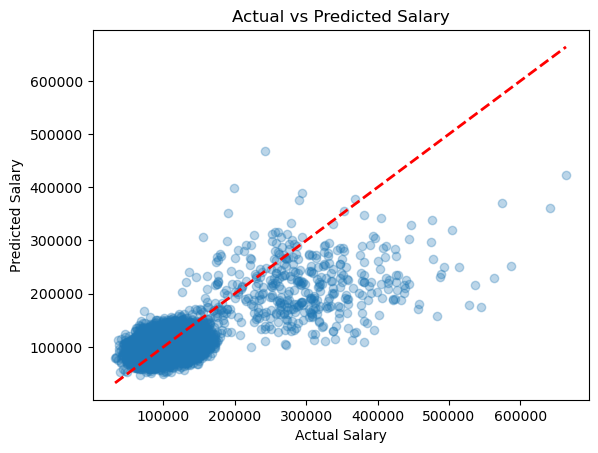

In [95]:
plt.scatter(Y_test , y_pred, alpha=0.3)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],'r--',linewidth=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

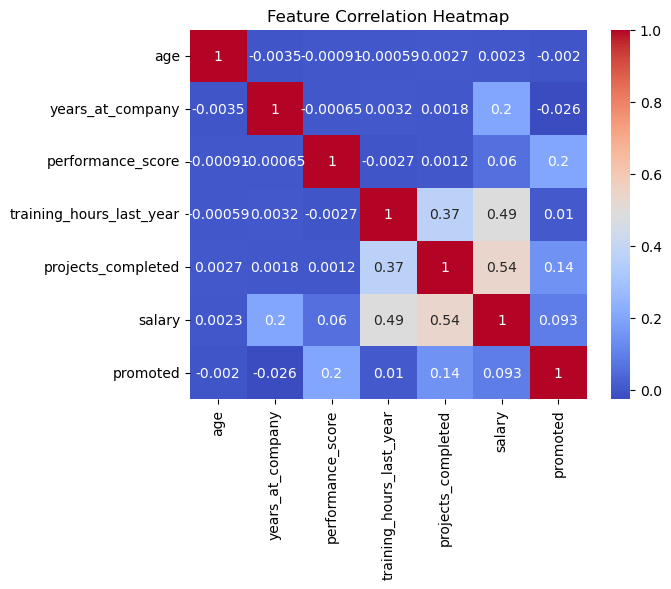

In [57]:
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
          

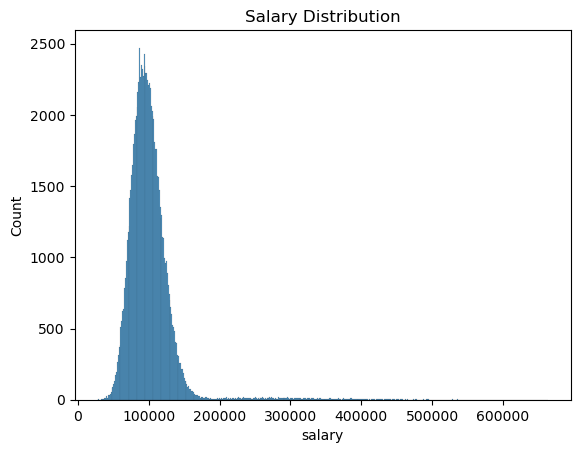

In [59]:
sns.histplot(data['salary'])
plt.title("Salary Distribution")
plt.show()

### Predict new employee salary

In [55]:
new_employee = scaler.transform([[30,5,80,40,12]])
prediction = model.predict(new_employee)
print(prediction)

[124665.16449265]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# B. Logistic Regression 
## Predict whether an employee will be promoted

### Divide x and y

In [26]:
x = df[['age','years_at_company','performance_score','training_hours_last_year','projects_completed','salary']]
y = df['promoted']
x

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary
0,50,10,100.000000,25.361303,4,137633.720337
1,36,9,72.008233,43.760654,9,114499.406460
2,29,7,77.244045,25.275693,7,124233.224752
3,42,4,49.061426,33.507680,4,100896.326509
4,40,2,89.021698,44.730269,6,93054.051809
...,...,...,...,...,...,...
99995,58,7,65.667405,44.196447,2,66709.407346
99996,48,1,65.879533,28.214698,4,126692.866136
99997,44,6,74.019251,47.025932,4,97701.247923
99998,47,10,42.735590,53.422399,9,92976.123220


In [27]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: promoted, Length: 100000, dtype: int64

### Train and Test Split

In [60]:
x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_test

,age,years_at_company,performance_score,training_hours_last_year,projects_completed,salary
75721,48,11,61.569049,46.592282,5,127269.603922
80184,54,6,44.909208,34.671245,8,104196.216921
19864,40,1,84.727623,54.084261,2,75473.743918
76699,37,4,40.000000,24.813713,2,110146.167810
92991,59,3,56.061030,30.549544,1,70457.941373
...,...,...,...,...,...,...
32595,36,5,75.844916,23.309500,2,91193.256924
29313,38,2,63.002196,38.890553,5,106675.027402
37862,38,7,57.035322,52.725140,1,95890.907997
53421,22,4,47.058619,36.250124,5,65646.026553


In [29]:
y_test

75721    0
80184    0
19864    0
76699    0
92991    0
        ..
32595    0
29313    0
37862    0
53421    0
42410    0
Name: promoted, Length: 20000, dtype: int64

In [30]:
x.columns

Index(['age', 'years_at_company', 'performance_score',
       'training_hours_last_year', 'projects_completed', 'salary'],
      dtype='object')

### Feature Scaling

In [49]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Train Logistic Model


In [78]:
classifier = LogisticRegression()
classifier.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predicton


In [79]:
y_predict = classifier.predict(x_test)

### Accuracy

In [80]:
accuracy = accuracy_score(y_test,y_predict)
print("Accuracy=", accuracy)

Accuracy= 0.8961


### Confusion Matrix


In [81]:
cm = confusion_matrix(y_test,y_predict)
print(cm)

[[17909    20]
 [ 2058    13]]


### Visualization

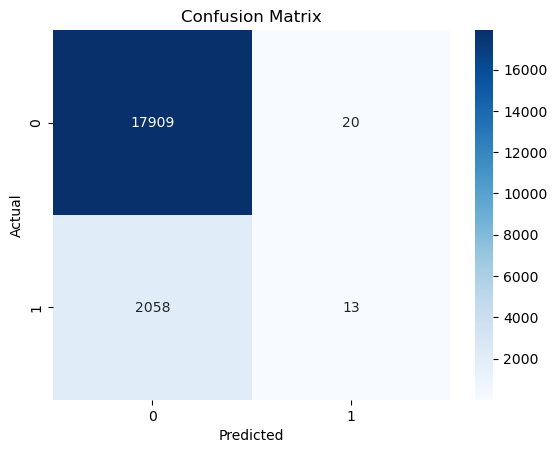

In [82]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Predict Promotion for New Employee ( 0--> Not to be promoted , 1--> Likely to be Promoted )


In [85]:
new_emp = scaler.transform([[30,5,80,40,12,150000]])
pred = classifier.predict(new_emp)
print(pred)

[1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [86]:
new_emp = scaler.transform([[30,7,80,40,22,200000]])
pred = classifier.predict(new_emp)
print(pred)

[1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
